In [1]:
# import stuff
import networkx as nx
import random
import MISC_Functions
import matplotlib.pyplot as plt

import asymmetree.treeevolve as te
from asymmetree.visualization.tree_vis import visualize, assign_colors
from asymmetree.analysis import bmg_from_tree, is_bmg

from bmg_fun import convert_to_nx
from bmg_Tony import bmg

from insert_hybrid import insertHybrid
from BICcherryRestrict import BICcherryRestrict
from BCEA import BCEA
from BCEA_multilayered import MLBCEA

In [2]:
# ############################################################## #
# Compare our bmg functions to asymmetree.analysis.bmg_from_tree #
# ############################################################## #

runs = 1
broken = False

for _ in range(runs):

    speciesTree, geneTree = MISC_Functions.generateTree(nSpecies = random.randint(2,10))

    # get color dicts
    species_colors, gene_colors = assign_colors(speciesTree, geneTree)

    # convert to networkx
    Tree = convert_to_nx(geneTree)

    # Beide Arten der BMGs
    ABMG = bmg_from_tree(geneTree)      # von Asymmetree (kann nur auf Trees angewendet werden)
    FBMG = bmg(Tree)                    # selbstgeschrieben mit memoization

    FBMG = nx.relabel_nodes(FBMG,int)


    if not is_bmg(ABMG):
        print("ABMG is not a BMG")
        broken = True
        break

    if not is_bmg(FBMG):
        print("BMG is not a FBMG")
        broken = True
        break

    if not nx.utils.graphs_equal(FBMG, ABMG):
        print("FBMG and ABMG differ")
        broken = True
        break


if broken:
    # visualize networks side by side

    # gene color dict turn keys to strings
    gene_colors_str = {str(k): v for k, v in gene_colors.items()}
    fig, axes = plt.subplots(1, 3, figsize=(20, 10))

    # pos argument for all plots
    pos = nx.circular_layout(FBMG)

    nodes_list = [v for v in FBMG.nodes()]
    nodes_colors = [gene_colors_str.get(v, "grey") for v in nodes_list]
    axes[0].set_title("BMG")
    nx.draw(FBMG, pos, nodelist=nodes_list, node_color= nodes_colors, ax=axes[0], with_labels=True)


    nodes_list = [v for v in ABMG.nodes()]
    nodes_colors = [gene_colors_str.get(v, "grey") for v in nodes_list]
    axes[1].set_title("ABMG")
    nx.draw(ABMG, pos, nodelist=nodes_list, node_color= nodes_colors, ax=axes[1], with_labels=True)

    nodes_list = [v for v in FBMG.nodes()]
    nodes_colors = [gene_colors_str.get(v, "grey") for v in nodes_list]
    axes[2].set_title("FBMG")
    nx.draw(ABMG, pos, nodelist=nodes_list, node_color= nodes_colors, ax=axes[1], with_labels=True)

if not broken:
    print("Both functions delivered the same BMG for all", runs, "runs")


Both functions delivered the same BMG for all 1 runs


In [3]:
# =====================================================================
# Test, ob der strong bmg für Genbäume immer mit BCEA darstellbar ist
# =====================================================================

runs = 1
mode = 'strong'
maxLeaves = 500
broken = False

for _ in range (runs):
    nLeaves = maxLeaves +1
    while nLeaves > maxLeaves:

        # species tree
        speciesTree = te.species_tree_n_age(
            age = 1.0,
            n = random.randint(2,4)
            #, contraction_probability=0.0, contraction_proportion=0.2, contraction_bias="exponential"
        )
        # gene tree
        T = te.dated_gene_tree(
            speciesTree, dupl_rate=1.0, loss_rate=0, hgt_rate=0.2, gc_rate=0.2, prohibit_extinction="per_species", dupl_polytomy=0.5
        )
        # prune all loss branches and the planted root
        geneTree = te.prune_losses(T)
        nLeaves = len(list(geneTree.leaves()))
    Tree = convert_to_nx(geneTree)

    # Original BMG:
    BMG = bmg(Tree, mode= mode)
    BC = BCEA(BMG, mode = mode)
    BMGBC = bmg(BC, mode= mode)

    if not nx.utils.graphs_equal(BMG, BMGBC):
        print("the BMG already breaks for the Tree")
        broken = True
        break

if not broken:
    print("Both functions delivered the same BMG for all", runs, "runs")


Both functions delivered the same BMG for all 1 runs


AttributeError: module 'MISC_Functions' has no attribute 'visualize_bmg_ax'

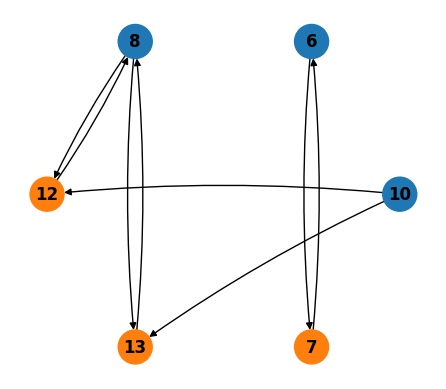

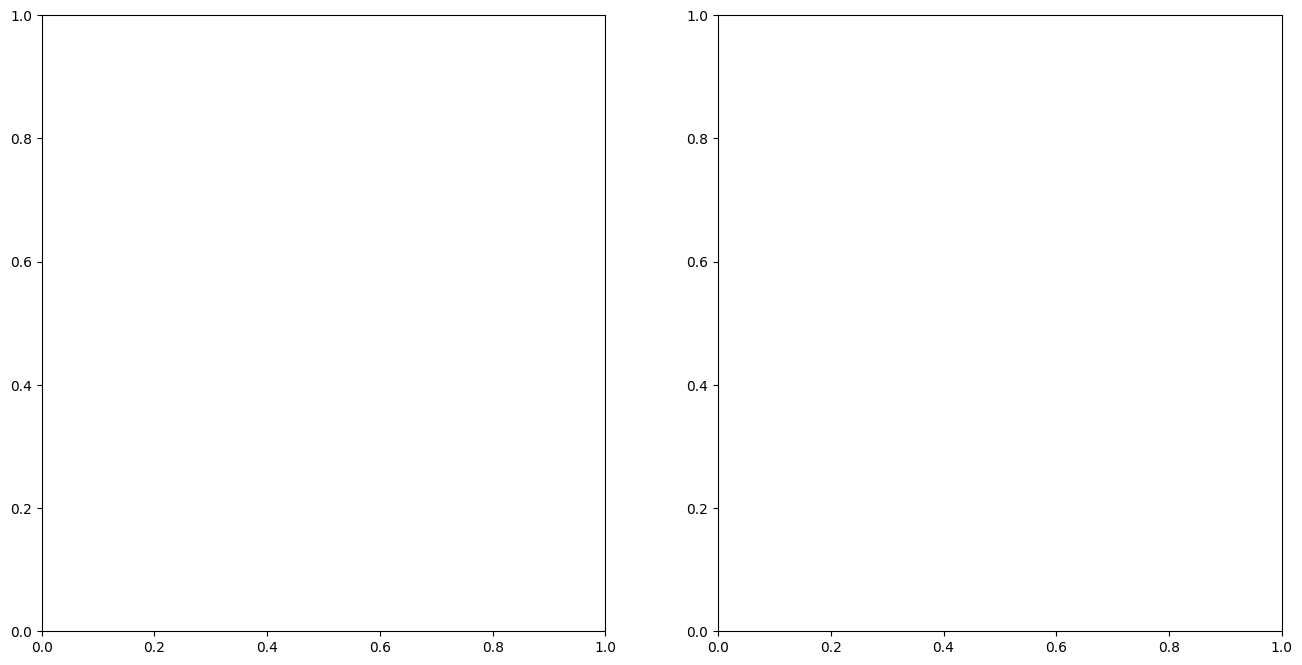

In [ ]:
MISC_Functions.visualize_bmg(BMG)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

MISC_Functions.visualize_bmg(BMG, ax=axes[0])
axes[0].set_title("BMG 1")

MISC_Functions.visualize_bmg(BMGBC, ax=axes[1])
axes[1].set_title("BMG 2")

plt.show()

In [ ]:
# ###################################################### #
# Compare BCEA and MultilayeredBCEA to BICcherryRestrict #
# ###################################################### #
runs = 1
mode = "strong"

broken = False

for _ in range(runs):

    speciesTree, geneTree = MISC_Functions.generateTree(nSpecies = random.randint(2,10))
    Tree = convert_to_nx(geneTree)

    BMG = bmg(Tree, mode = mode)

    RBCN = BICcherryRestrict(BMG)
    RBMG = bmg(RBCN, mode = mode)
    # testABMG = nx.utils.graphs_equal(BMG, ABMG)

    ABCN = BCEA(BMG)
    ABMG = bmg(ABCN, mode = mode)
    # testRBMG = nx.utils.graphs_equal(BMG, RBMG)


    # MLBCN = MLBCEA(BMG)
    # MLBMG = bmg(MLBCN, mode = mode)
    # testMLBMG = nx.utils.graphs_equal(BMG, MLBMG)

    # print("A:", testABMG, "R:", testRBMG)  # "ML:", testMLBMG)
    
    if not nx.utils.graphs_equal(RBMG, ABMG):
        print("ALAAAAARM!")
        broken = True
        break

if not broken:
    print("Both functions delivered the same BMG for all", runs, "runs")

Both functions delivered the same BMG for all 1 runs
